REGRESSION ANALYSIS

#Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [1]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 11.2/11.2 MB 3.5 MB/s eta 0:00:00
     ---------------------------------------- 46.2/46.2 MB 3.4 MB/s eta 0:00:00
     -------------------------------------- 309.1/309.1 KB 3.2 MB/s eta 0:00:00


You should consider upgrading via the 'C:\Program Files (x86)\Microsoft Visual Studio\Shared\Python39_64\python.exe -m pip install --upgrade pip' command.


In [4]:
import sklearn

print(sklearn.__version__)

1.6.1


#Load Dataset

In [15]:
df = pd.read_csv(
    r"C:\Users\Admin\Downloads\house presiction\house Prediction Data Set.csv",
    sep=r"\s+",
    header=None
)

In [18]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


#Assign Column Name

In [17]:
columns = [
    'CRIM','ZN','INDUS','CHAS','NOX',
    'RM','AGE','DIS','RAD','TAX',
    'PTRATIO','B','LSTAT','MEDV'
]

df.columns = columns

In [ ]:
#Chech few Rows

In [19]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


#Check Data Structure

#Checking for the Dimension

In [20]:
df.shape

(506, 14)

#Chechk for Data type

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [ ]:
#Check for Missing Value

In [22]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [ ]:
#Statiscal Summary

In [23]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


#Select Variables
Use:
RM = Predictor (X)
MEDV = Target (y)

In [24]:
X = df[['RM']]
y = df['MEDV']

#Visualize the relationship

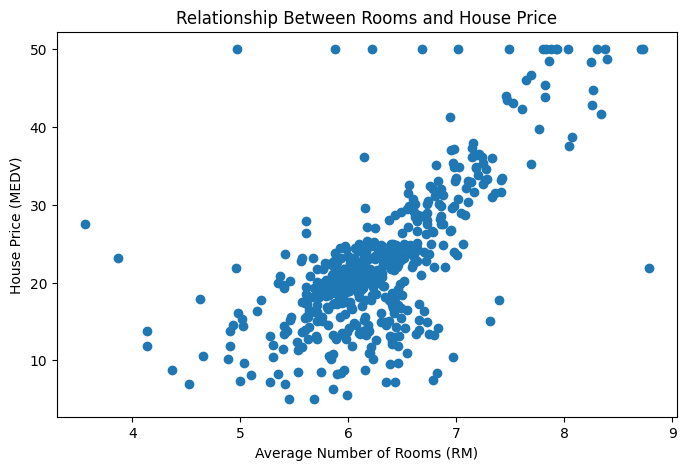

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(X, y)
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Price (MEDV)")
plt.title("Relationship Between Rooms and House Price")
plt.show()

#Split Data into Training and Testing set

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Check size of Data set

In [27]:
print(X_train.shape)
print(X_test.shape)

(404, 1)
(102, 1)


#Create and Traing the Model

In [28]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

#View Coefficient

In [29]:
print("Intercept:", model.intercept_)

Intercept: -36.24631889813792


#Slope Coefficient

In [30]:
print("Coefficient:", model.coef_[0])

Coefficient: 9.348301406497722


In [ ]:
#Interpret the Coefficient

Regression Equation:

MEDV=Intercept+(Coefficient×RM)

For example:

MEDV=−36.25+9.34(RM)

For every additional room in a house, the predicted house price increases by approximately 9.34 units.

In [31]:
y_pred = model.predict(X_test)

#View First Few Prediction

In [32]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head()

,Actual,Predicted
173,23.6,23.732383
274,32.4,26.929502
491,13.6,19.684568
72,22.8,20.451129
452,16.1,22.619935


#Evaluate the Model
Mean Squared Error (MSE)

In [33]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 46.144775347317264


#R-Square

In [34]:
r2 = r2_score(y_test, y_pred)

print("R-Squared:", r2)

R-Squared: 0.3707569232254778


#Plot Regression Line

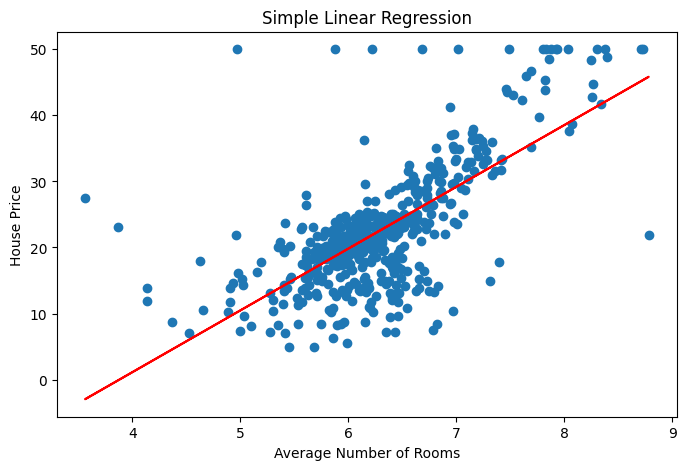

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.plot(
    X,
    model.predict(X),
    color='red'
)

plt.xlabel("Average Number of Rooms")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.show()